In [1]:
# Install required packages if not already installed
import sys
import subprocess

def install_package(package):
    subprocess.check_call([sys.executable, "-m", "pip", "install", package])

# Check and install necessary packages
required_packages = ['numpy', 'matplotlib','scipy']
for package in required_packages:
    try:
        # Just try importing - don't assign to a variable
        __import__(package)
        print(f"✅ {package} is already installed")
    except ImportError:
        print(f"📥 Installing {package}...")
        install_package(package)
        # Try importing again after installation
        try:
            __import__(package)
            print(f"✅ {package} has been installed")
        except ImportError:
            print(f"❌ Failed to install {package}")


# Libraries
import numpy as np
from numpy.fft import fftshift, fft2,fft, fftfreq
import random

from scipy.signal import butter,lfilter, filtfilt, hilbert

import matplotlib.pyplot as plt  # data plotting 
from matplotlib.pyplot import figure
from matplotlib import rcParams

rcParams['figure.figsize']     = [15,6] 
rcParams['lines.markersize']   = 6         # marker size in points
plt.rcParams['axes.labelsize'] = 9
plt.rcParams['axes.titlesize'] = 9
plt.rcParams['figure.dpi']     = 120

✅ numpy is already installed
✅ matplotlib is already installed
✅ scipy is already installed


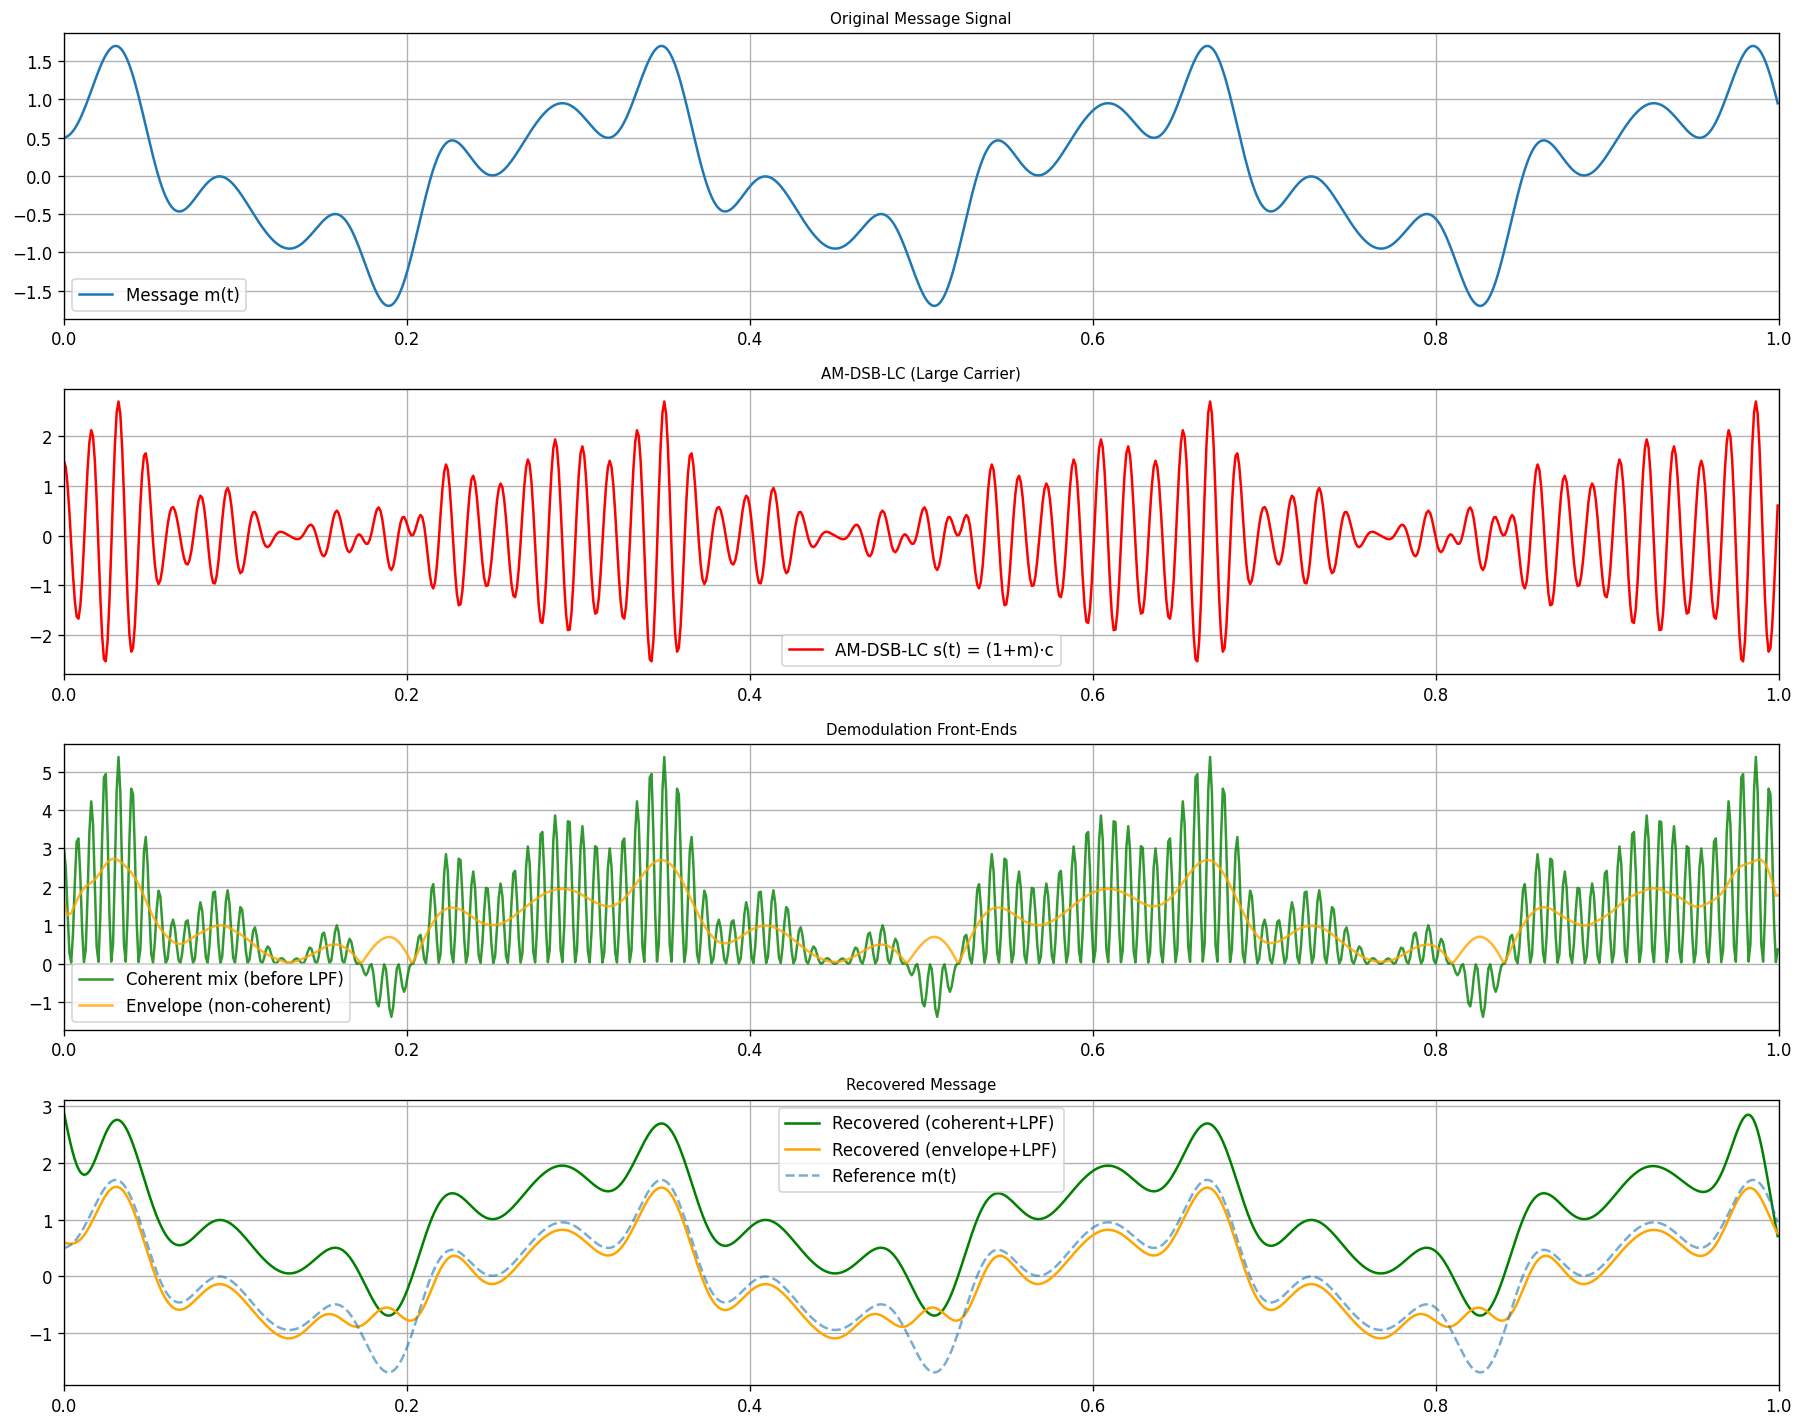

In [2]:
def generate_signals():
    # Parameters (treat these as Hz even if multiples of pi are used)
    Fs = 300 * np.pi                 # sampling frequency [Hz]
    t = np.arange(0, 1, 1 / Fs)      # 1 second

    fc = 20 * np.pi                  # carrier frequency [Hz]
    fm = 1 * np.pi                   # base message tone [Hz]

    # Multi-tone message
    message = (
        np.cos(2 * np.pi * fm * t)
        + 0.3 * np.sin(2 * np.pi * 3 * fm * t)
        - 0.5 * np.cos(2 * np.pi * 5 * fm * t)
        - 0.1 * np.sin(2 * np.pi * 7 * fm * t)
    )

    carrier = np.cos(2 * np.pi * fc * t)

    # AM-DSB-LC (large carrier). NOTE: This is NOT DSB-SC.
    am_dsb_lc_signal = (1 + message) * carrier

    return t, message, am_dsb_lc_signal, fc, Fs

def butter_lowpass(cutoff, fs, order=5):
    nyq = 0.5 * fs
    normal_cutoff = cutoff / nyq
    b = np.zeros(order + 1)
    a = np.zeros(order + 1)
    from scipy.signal import butter as _butter
    b, a = _butter(order, normal_cutoff, btype='low', analog=False)
    return b, a

def butter_lowpass_filter_zero_phase(data, cutoff, fs, order=5):
    b, a = butter_lowpass(cutoff, fs, order=order)
    # zero-phase filtering for clean classroom visuals
    y = filtfilt(b, a, data)
    return y

def coherent_demodulation_am_lc(modulated_signal, fc, t, cutoff, fs):
    """Coherent demodulation for AM-DSB-LC (works also for DSB-SC)."""
    local_carrier = np.cos(2 * np.pi * fc * t)
    baseband = modulated_signal * (2 * local_carrier)        # scale 2 helps recover amplitude
    recovered = butter_lowpass_filter_zero_phase(baseband, cutoff, fs)
    return baseband, recovered

def envelope_demodulation_am_lc(modulated_signal, cutoff, fs):
    """True non-coherent demodulation for AM-DSB-LC via Hilbert envelope."""
    analytic = hilbert(modulated_signal)
    env = np.abs(analytic)
    # Remove DC offset from the large carrier; approximate message
    # (For ideal AM with unit carrier term, envelope ≈ 1 + m(t))
    recovered = env - np.mean(env)
    # Optional: light LPF to smooth residual ripple
    recovered = butter_lowpass_filter_zero_phase(recovered, cutoff, fs)
    return env, recovered

def plot_signals(t, message, modulated_signal,
                 demo_coh_raw, demo_noncoh_env,
                 rec_coh, rec_noncoh):
    plt.figure(figsize=(15, 12))

    plt.subplot(4, 1, 1)
    plt.plot(t, message, label='Message m(t)')
    plt.xlim(0, 1)  # ~5 cycles of the lowest component
    plt.title('Original Message Signal'); plt.grid(True); plt.legend()

    plt.subplot(4, 1, 2)
    plt.plot(t, modulated_signal, label='AM-DSB-LC s(t) = (1+m)·c', color='red')
    plt.xlim(0,  1)
    plt.title('AM-DSB-LC (Large Carrier)'); plt.grid(True); plt.legend()

    plt.subplot(4, 1, 3)
    plt.plot(t, demo_coh_raw, label='Coherent mix (before LPF)', color='green', alpha=0.8)
    plt.plot(t, demo_noncoh_env, label='Envelope (non-coherent)', color='orange', alpha=0.8)
    plt.xlim(0,  1)
    plt.title('Demodulation Front-Ends'); plt.grid(True); plt.legend()

    plt.subplot(4, 1, 4)
    plt.plot(t, rec_coh, label='Recovered (coherent+LPF)', color='green')
    plt.plot(t, rec_noncoh, label='Recovered (envelope+LPF)', color='orange')
    plt.plot(t, message, '--', alpha=0.6, label='Reference m(t)')
    plt.xlim(0,  1)
    plt.title('Recovered Message'); plt.grid(True); plt.legend()

    plt.tight_layout(); plt.show()

def main():
    t, message, am_dsb_lc_signal, fc, Fs = generate_signals()

    # Choose LPF cutoff safely above the highest message component (7*fm ≈ 7π Hz)
    cutoff = 10 * np.pi

    # Coherent demod (works for AM-DSB-LC and DSB-SC)
    coh_raw, coh_rec = coherent_demodulation_am_lc(am_dsb_lc_signal, fc, t, cutoff, Fs)

    # Non-coherent demod: true envelope detection
    env, env_rec = envelope_demodulation_am_lc(am_dsb_lc_signal, cutoff, Fs)

    plot_signals(t, message, am_dsb_lc_signal, coh_raw, env, coh_rec, env_rec)

if __name__ == "__main__":
    main()


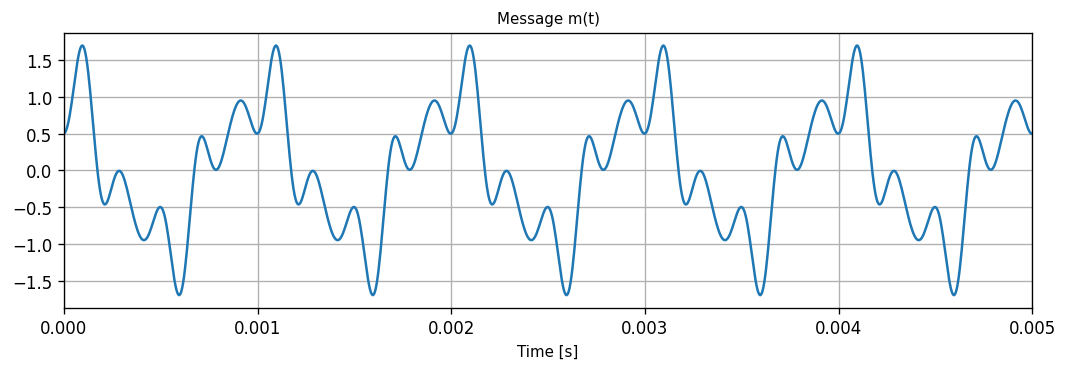

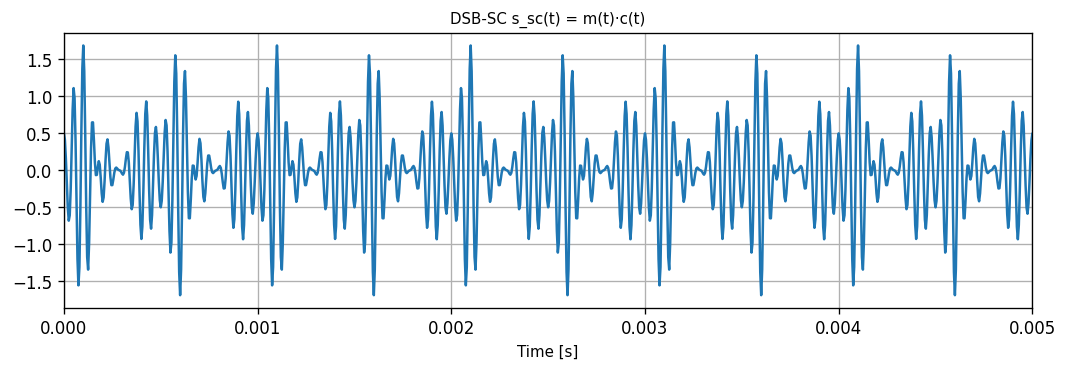

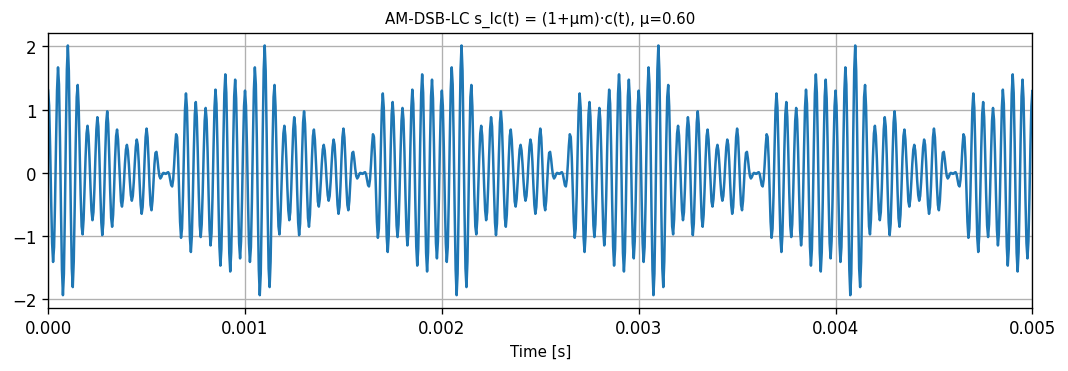

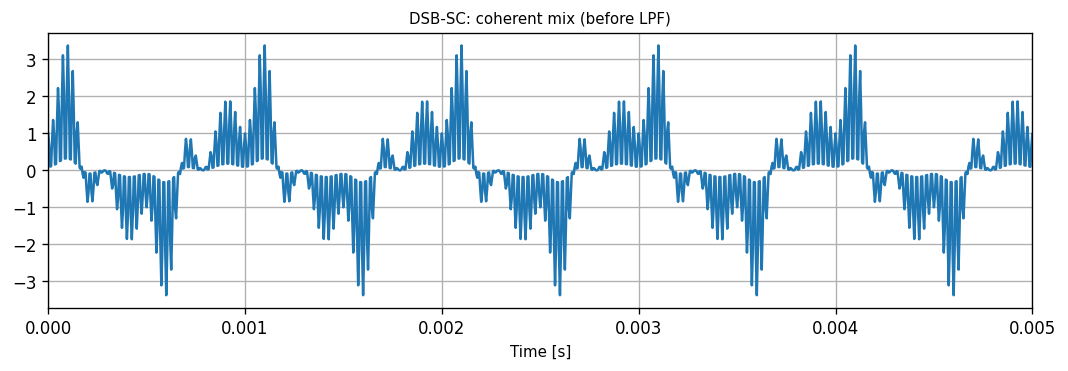

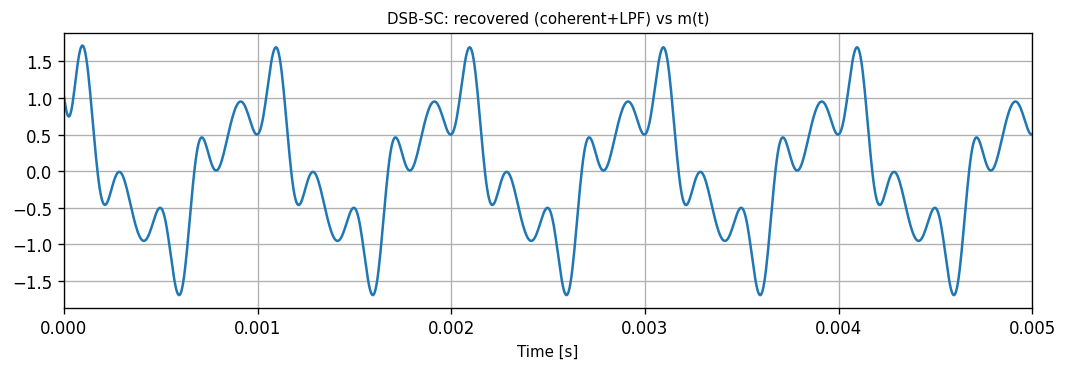

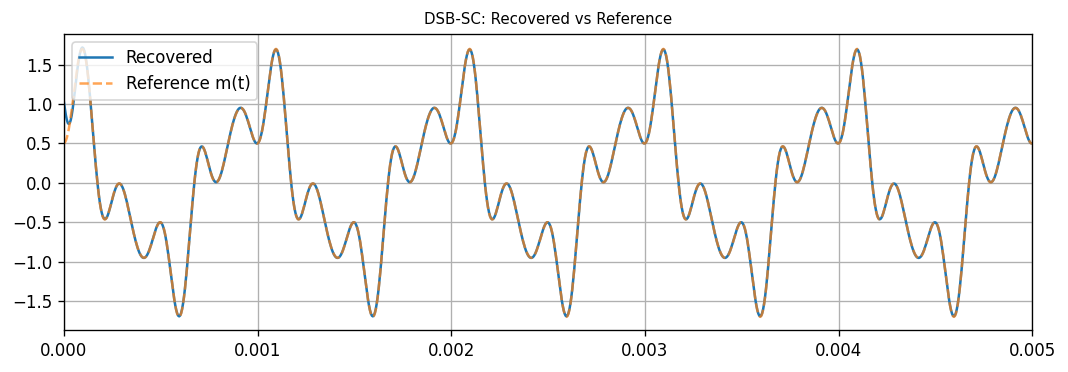

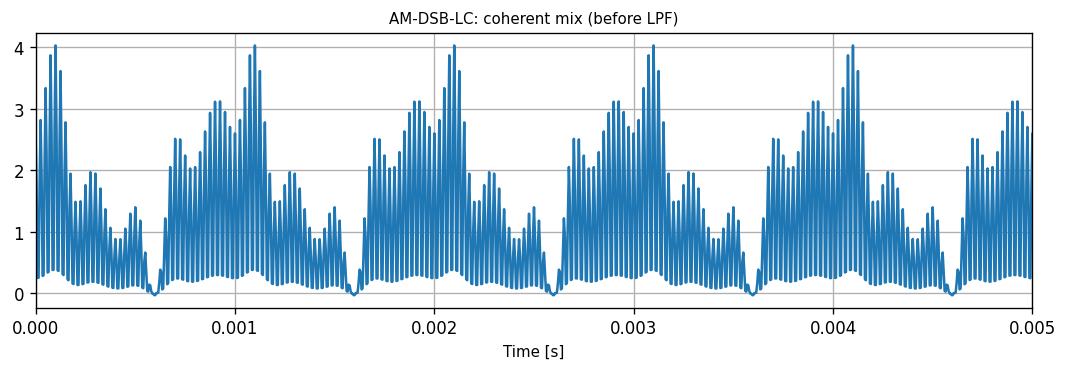

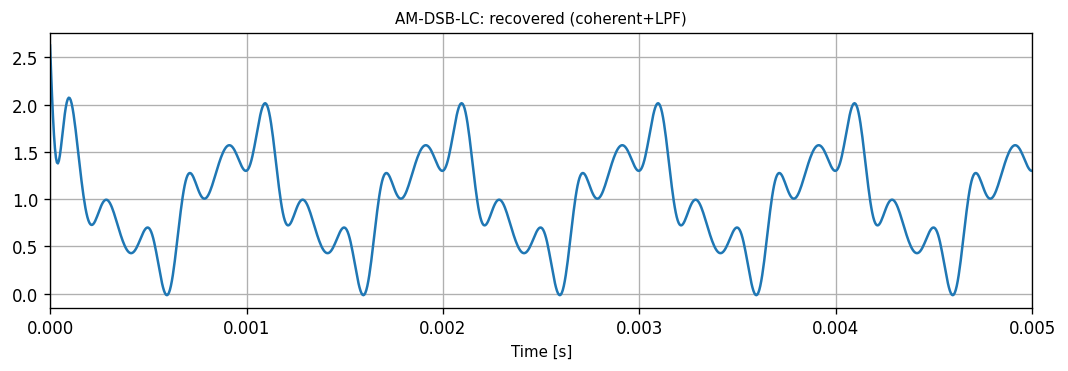

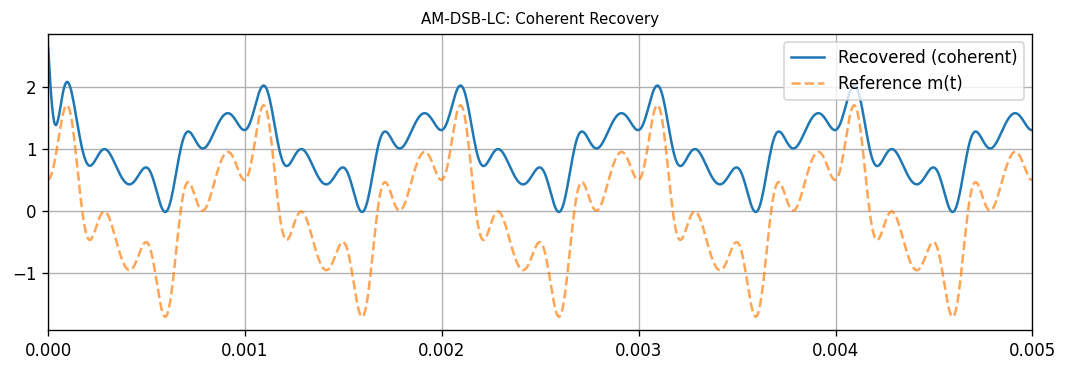

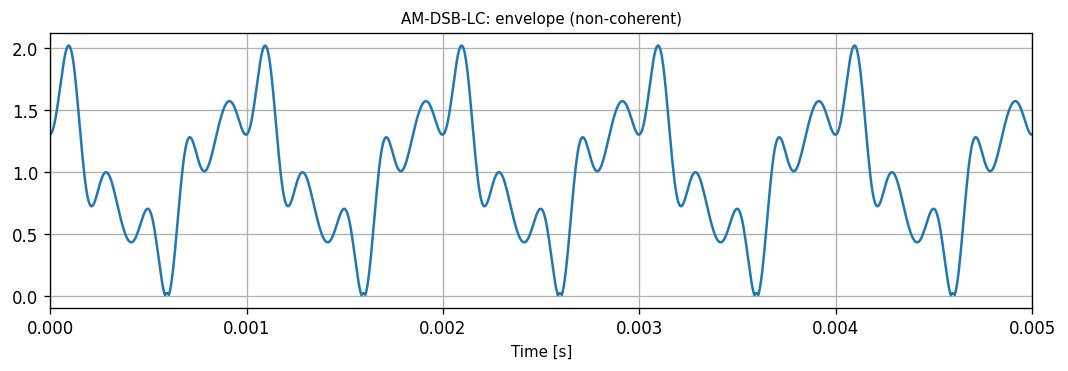

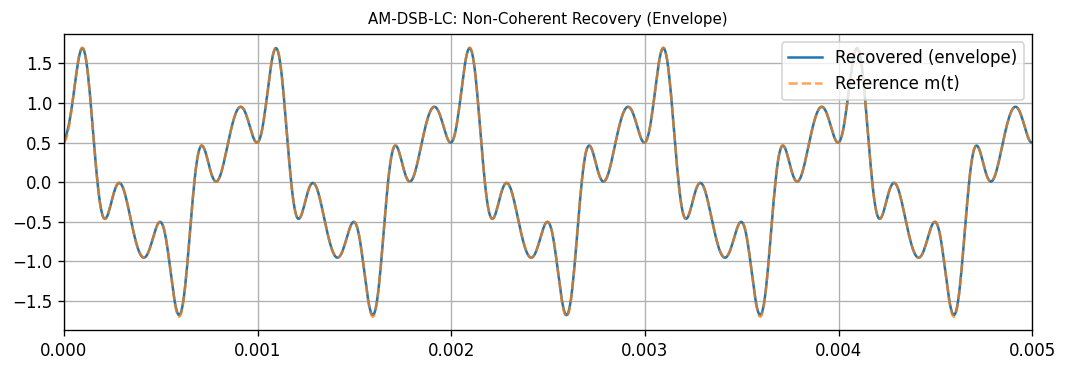

In [3]:
# ----------------- Parameters (Hz, s) -----------------
Fs = 200_000
Ts = 1 / Fs
T  = 0.02                    # 20 ms
t  = np.arange(0, T, Ts)

fm = 1_000                   # 1 kHz message
fc = 20_000                  # 20 kHz carrier
mu = 0.6                     # modulation index (valid envelope if 0<mu<=1)

# Multi-tone message around 1 kHz band (kept small so |m(t)|<=1 roughly)
m = (np.cos(2*np.pi*fm*t)
     + 0.3*np.sin(2*np.pi*3*fm*t)
     - 0.5*np.cos(2*np.pi*5*fm*t)
     - 0.1*np.sin(2*np.pi*7*fm*t))

c = np.cos(2*np.pi*fc*t)

# ----------------- Modulators -----------------
s_sc = m * c                         # DSB-SC
s_lc = (1 + mu*m) * c                # AM-DSB-LC

# ----------------- Filters -----------------
def lpf_zp(x, cutoff_hz, fs, order=4):
    from scipy.signal import butter
    b, a = butter(order, cutoff_hz/(fs/2), btype='low')
    return filtfilt(b, a, x)

# ----------------- Coherent demod (works for both) -----------------
def coherent_demod(s, fc, t, cutoff, fs):
    lo = np.cos(2*np.pi*fc*t)
    bb = s * (2*lo)                  # scale 2 for amplitude recovery
    rec = lpf_zp(bb, cutoff, fs)
    return bb, rec

# ----------------- Envelope demod (AM-DSB-LC only) -----------------
def envelope_demod_am_lc(s, cutoff, fs, mu):
    a = hilbert(s)
    env = np.abs(a)                  # ≈ 1 + mu*m(t)
    rec = (env - np.mean(env)) / mu  # ≈ m(t)
    rec = lpf_zp(rec, cutoff, fs)
    return env, rec

cutoff = 10_000                      # cutoff > highest message (here 7 kHz), < fc

# DSB-SC coherent
sc_bb, sc_rec = coherent_demod(s_sc, fc, t, cutoff, Fs)

# AM-DSB-LC coherent + envelope
lc_bb, lc_rec_coh = coherent_demod(s_lc, fc, t, cutoff, Fs)
lc_env, lc_rec_env = envelope_demod_am_lc(s_lc, cutoff, Fs, mu)

# ----------------- Plots -----------------
def show_time(sig, ttl, cycles=5):
    plt.figure(figsize=(9,3.2))
    plt.plot(t, sig); plt.xlim(0, cycles/fm); plt.title(ttl)
    plt.xlabel('Time [s]'); plt.grid(True); plt.tight_layout(); plt.show()

show_time(m, 'Message m(t)')
show_time(s_sc, 'DSB-SC s_sc(t) = m(t)·c(t)')
show_time(s_lc, f'AM-DSB-LC s_lc(t) = (1+μm)·c(t), μ={mu:.2f}')

show_time(sc_bb, 'DSB-SC: coherent mix (before LPF)')
show_time(sc_rec, 'DSB-SC: recovered (coherent+LPF) vs m(t)')
plt.figure(figsize=(9,3.2)); plt.plot(t, sc_rec, label='Recovered')
plt.plot(t, m, '--', alpha=0.7, label='Reference m(t)')
plt.xlim(0, 5/fm); plt.title('DSB-SC: Recovered vs Reference'); plt.grid(True); plt.legend(); plt.tight_layout(); plt.show()

show_time(lc_bb, 'AM-DSB-LC: coherent mix (before LPF)')
show_time(lc_rec_coh, 'AM-DSB-LC: recovered (coherent+LPF)')
plt.figure(figsize=(9,3.2)); plt.plot(t, lc_rec_coh, label='Recovered (coherent)')
plt.plot(t, m, '--', alpha=0.7, label='Reference m(t)')
plt.xlim(0, 5/fm); plt.title('AM-DSB-LC: Coherent Recovery'); plt.grid(True); plt.legend(); plt.tight_layout(); plt.show()

show_time(lc_env, 'AM-DSB-LC: envelope (non-coherent)')
plt.figure(figsize=(9,3.2)); plt.plot(t, lc_rec_env, label='Recovered (envelope)')
plt.plot(t, m, '--', alpha=0.7, label='Reference m(t)')
plt.xlim(0, 5/fm); plt.title('AM-DSB-LC: Non-Coherent Recovery (Envelope)'); plt.grid(True); plt.legend(); plt.tight_layout(); plt.show()


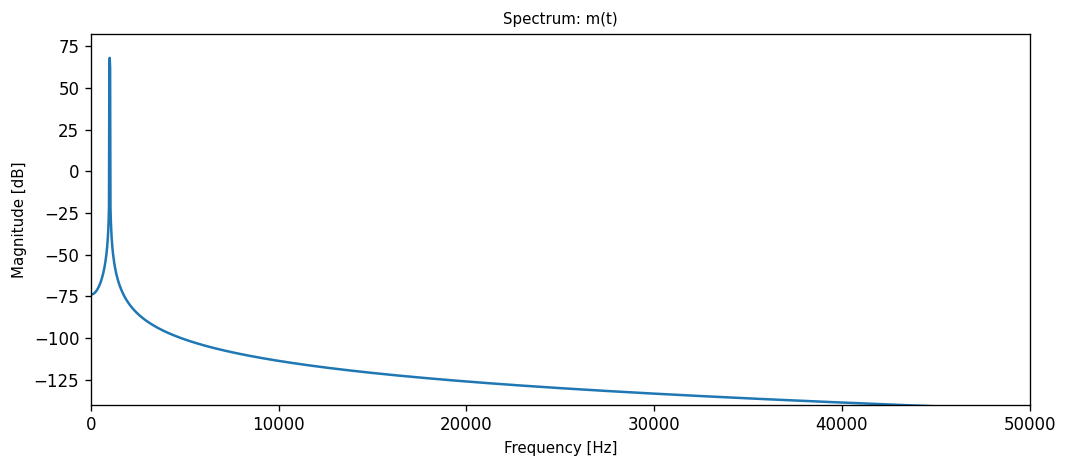

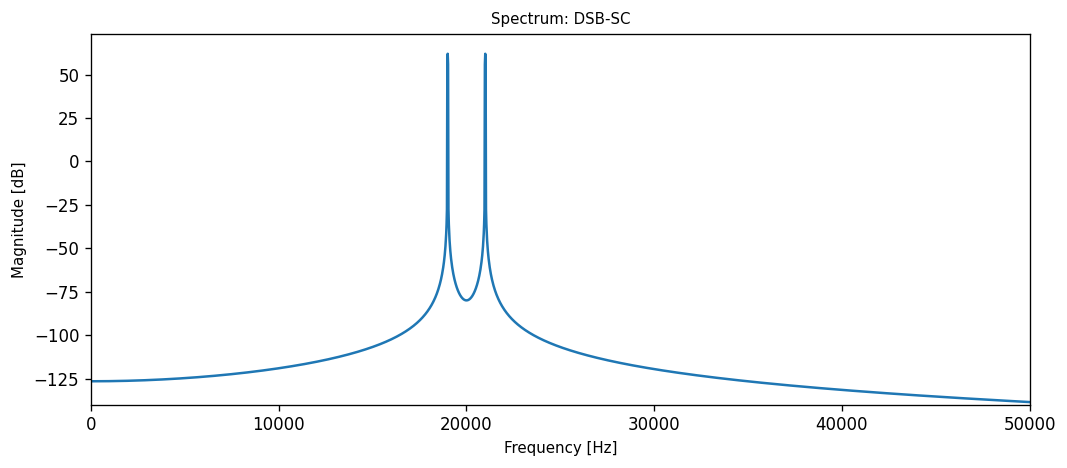

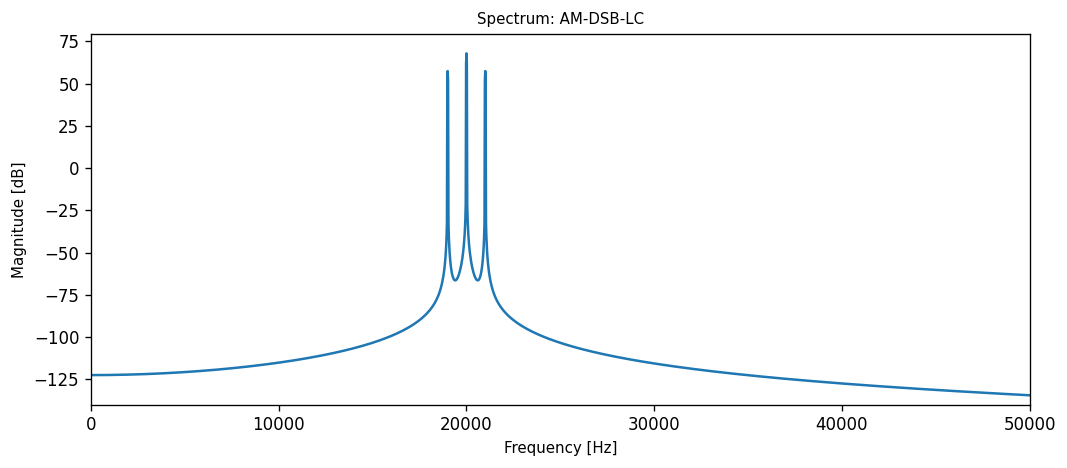

In [4]:
# --- Parameters (Hz, seconds) ---
Fs = 200_000      # sampling rate
Ts = 1 / Fs
T  = 0.05         # 50 ms
t  = np.arange(0, T, Ts)

fm = 1_000        # message frequency (1 kHz)
fc = 20_000       # carrier (20 kHz)
mu = 0.6          # modulation index for AM-DSB-LC (0 < mu <= 1)

# --- Message and carrier ---
m = np.cos(2*np.pi*fm*t)                  # unit-amplitude baseband
c = np.cos(2*np.pi*fc*t)

# --- DSB-SC and AM-DSB-LC ---
s_sc  = m * c                              # DSB-SC
s_lc  = (1 + mu*m) * c                     # AM-DSB-LC (envelope should be 1+mu*m if mu<=1)

# --- Coherent demod (example on DSB-SC) ---
x_mix = s_sc * (2*c)                       # multiply by synchronized carrier (scale 2 for power)
# LPF design
def lpf(sig, fc_hz):
    b, a = butter(4, fc_hz/(Fs/2), btype='low')
    return filtfilt(b, a, sig)

m_rec_sc = lpf(x_mix, 2*fm)                # cutoff just above message band

# --- Envelope demod (works for AM-DSB-LC, not DSB-SC) ---
analytic = hilbert(s_lc)
env = np.abs(analytic)
m_rec_env = (env - np.mean(env)) / mu      # re-center and scale to approximate m

# --- Quick spectrum helper ---
def mag_spectrum(x):
    N = len(x)
    X = np.fft.rfft(x*np.hanning(N))
    f = np.fft.rfftfreq(N, Ts)
    return f, 20*np.log10(np.maximum(np.abs(X), 1e-12))

for label, sig in [('m(t)', m), ('DSB-SC', s_sc), ('AM-DSB-LC', s_lc)]:
    f, M = mag_spectrum(sig)
    plt.figure(figsize=(9,4))
    plt.plot(f, M); plt.xlim(0, 50_000); plt.ylim(-140, None)
    plt.xlabel('Frequency [Hz]'); plt.ylabel('Magnitude [dB]'); plt.title(f'Spectrum: {label}')
    plt.tight_layout(); plt.show()
